In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
sns.set_palette("deep")

In [ ]:
books = pd.read_csv(r"data\Books.csv")
users = pd.read_csv(r"data\Users.csv")
ratings = pd.read_csv(r"data\Ratings.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_25844\3240047533.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv(r"C:\Users\HP\Downloads\Books.csv")


In [3]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [4]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [5]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [6]:
print(books.shape)
print(users.shape)
print(ratings.shape)

(271360, 8)
(278858, 3)
(1149780, 3)


In [7]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [8]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [9]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [10]:
books.duplicated().sum()

np.int64(0)

In [11]:
users.duplicated().sum()

np.int64(0)

In [12]:
ratings.duplicated().sum()

np.int64(0)

In [13]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [14]:
books.describe()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
count,271360,271360,271358,271360,271358,271360,271360,271357
unique,271360,242135,102022,202,16807,271044,271044,271041
top,0195153448,Selected Poems,Agatha Christie,2002,Harlequin,http://images.amazon.com/images/P/155936078X.0...,http://images.amazon.com/images/P/155936078X.0...,http://images.amazon.com/images/P/155936078X.0...
freq,1,27,632,13903,7535,2,2,2


In [15]:
ratings.describe()

,User-ID,Book-Rating
count,1.149780e+06,1.149780e+06
mean,1.403864e+05,2.866950e+00
std,8.056228e+04,3.854184e+00
min,2.000000e+00,0.000000e+00
25%,7.034500e+04,0.000000e+00
50%,1.410100e+05,0.000000e+00
75%,2.110280e+05,7.000000e+00
max,2.788540e+05,1.000000e+01


In [16]:
users.describe()

,User-ID,Age
count,278858.00000,168096.000000
mean,139429.50000,34.751434
std,80499.51502,14.428097
min,1.00000,0.000000
25%,69715.25000,24.000000
50%,139429.50000,32.000000
75%,209143.75000,44.000000
max,278858.00000,244.000000


In [17]:
books.columns

Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
       'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
      dtype='object')

In [18]:
books['Book-Author'] = books['Book-Author'].fillna('Unknown')
books['Publisher'] = books['Publisher'].fillna('Unknown')
books['Image-URL-L'] = books['Image-URL-L'].fillna(books['Image-URL-M'])

In [19]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            0
dtype: int64

In [20]:
users['country'] = users['Location'].str.split(",").str[-1].str.strip().str.capitalize()

In [21]:
users['country'].value_counts()

country
Usa               139711
Canada             21658
United kingdom     18538
Germany            17043
Spain              13147
                   ...  
Tyrtyrt                1
Mozambique"            1
Liushi                 1
Bih                    1
Lane                   1
Name: count, Length: 709, dtype: int64

In [22]:
users["User-ID"].duplicated().sum()

np.int64(0)

In [23]:
users.drop('Age', axis=1, inplace=True)

In [24]:
users.head()

,User-ID,Location,country
0,1,"nyc, new york, usa",Usa
1,2,"stockton, california, usa",Usa
2,3,"moscow, yukon territory, russia",Russia
3,4,"porto, v.n.gaia, portugal",Portugal
4,5,"farnborough, hants, united kingdom",United kingdom


In [25]:
top_books = ratings.groupby('ISBN')['Book-Rating'].count().sort_values(ascending=False).head(10)
print(top_books)

ISBN
0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
044023722X     647
0679781587     639
0142001740     615
067976402X     614
0671027360     586
Name: Book-Rating, dtype: int64


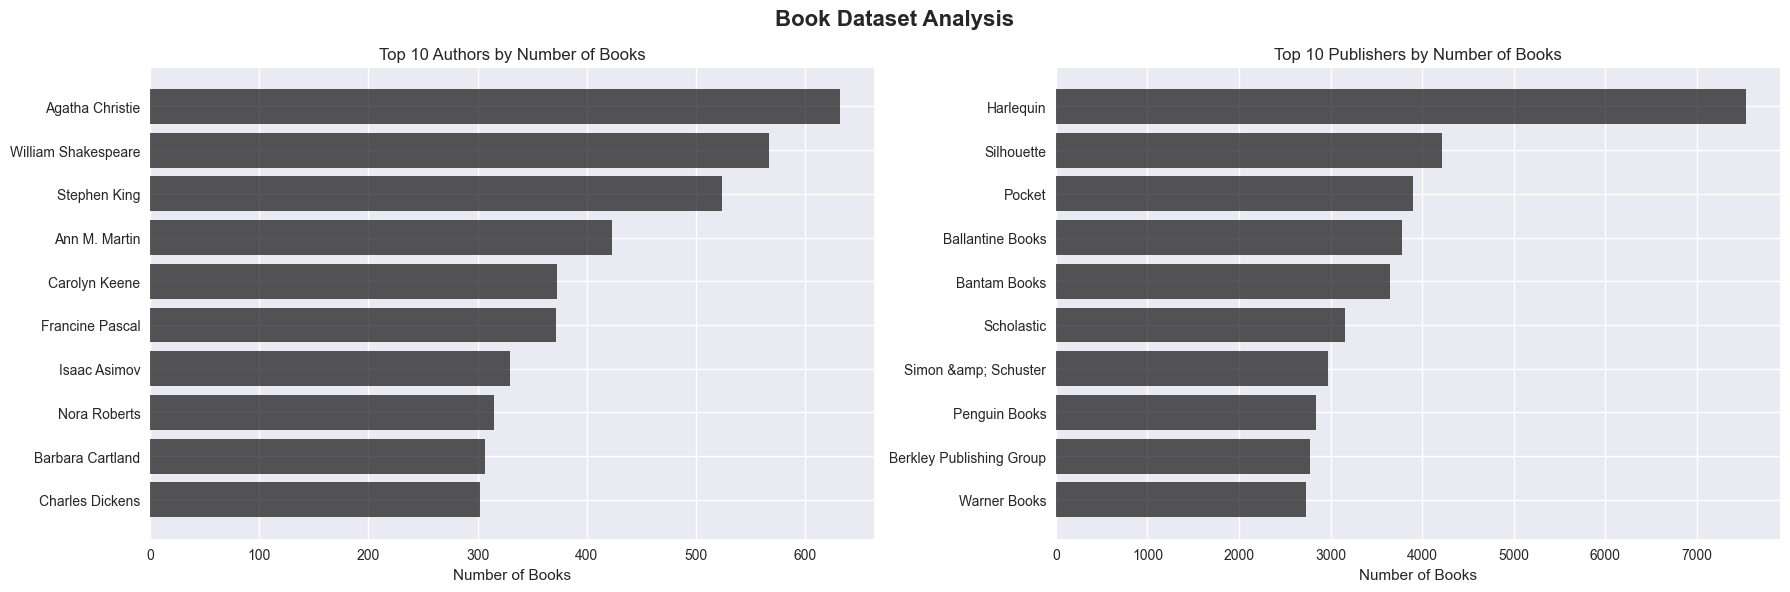

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_authors = books['Book-Author'].value_counts().head(10)
axes[0].barh(top_authors.index, top_authors.values, color='black', alpha = 0.65)
axes[0].set_title('Top 10 Authors by Number of Books')
axes[0].set_xlabel('Number of Books')
axes[0].invert_yaxis() 

top_publishers = books['Publisher'].value_counts().head(10)
axes[1].barh(top_publishers.index, top_publishers.values, color='black', alpha= 0.65)
axes[1].set_title('Top 10 Publishers by Number of Books')
axes[1].set_xlabel('Number of Books')
axes[1].invert_yaxis()

plt.suptitle('Book Dataset Analysis', fontsize =16 , fontweight='bold')
plt.tight_layout()
plt.show()

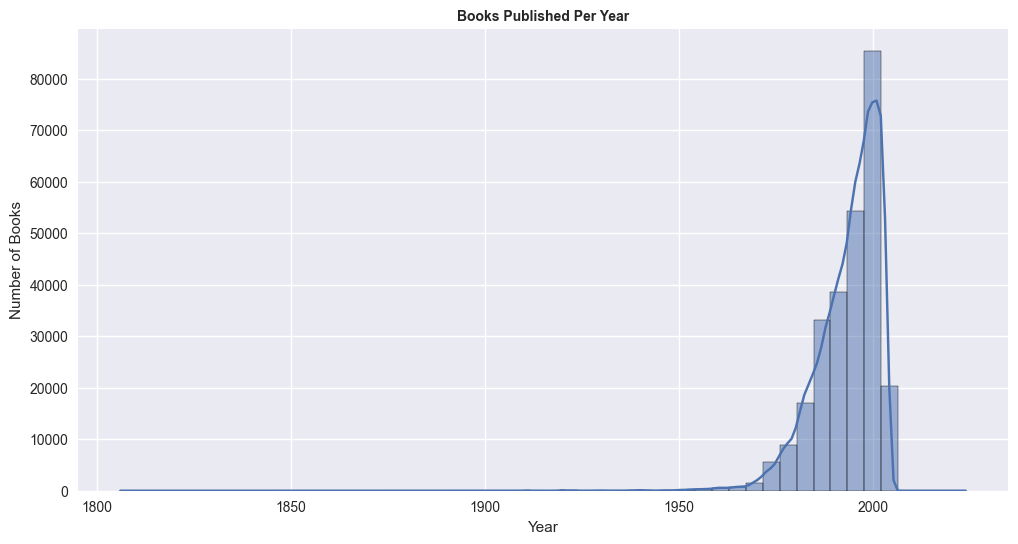

In [27]:
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
books = books[(books['Year-Of-Publication'] > 1800) & (books['Year-Of-Publication'] <= 2024)]
plt.figure(figsize=(12,6))
sns.histplot(data=books, x='Year-Of-Publication', bins=50, kde=True )
plt.title('Books Published Per Year', fontsize=10, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Books')
plt.show()

In [28]:
ratings_with_title = ratings.merge(books[['ISBN', 'Book-Title']], on='ISBN')
ratings_with_title.shape

(1017068, 4)

In [29]:
num_rating_df = ratings_with_title.groupby('Book-Title')['Book-Rating'].count().reset_index()
top_books = num_rating_df.sort_values('Book-Rating', ascending=False).head(10)
print(top_books)                                                              

                                             Book-Title  Book-Rating
231421                                      Wild Animus         2502
193167                        The Lovely Bones: A Novel         1295
180449                                The Da Vinci Code          897
5262                                    A Painted House          838
196075                       The Nanny Diaries: A Novel          828
27560                             Bridget Jones's Diary          815
203320                          The Secret Life of Bees          774
52119   Divine Secrets of the Ya-Ya Sisterhood: A Novel          740
201213              The Red Tent (Bestselling Backlist)          723
14265                               Angels &amp; Demons          670


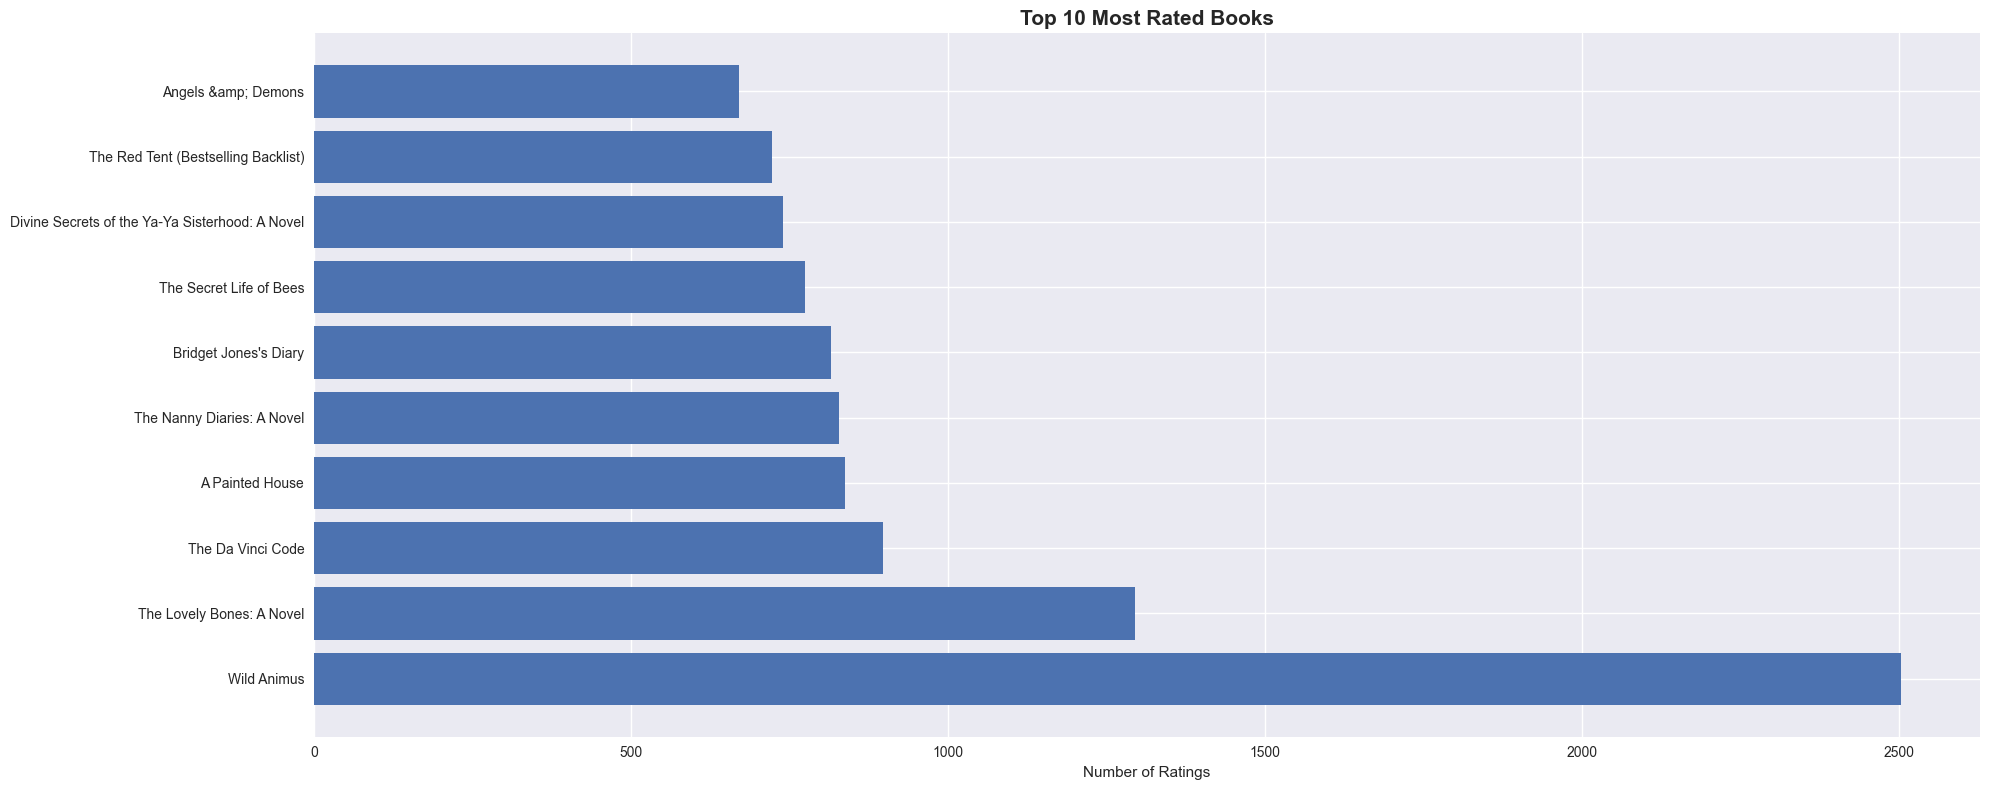

In [30]:
plt.figure(figsize=(20,8))
plt.barh(top_books['Book-Title'], top_books['Book-Rating'])
plt.title('Top 10 Most Rated Books', fontsize=15, fontweight='bold')
plt.xlabel('Number of Ratings')

plt.tight_layout()
plt.show()

In [31]:
num_rating_df.rename(columns={'Book-Rating' : 'num-rating'}, inplace=True)
num_rating_df

,Book-Title,num-rating
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
237444,Ã?Â?lpiraten.,2
237445,Ã?Â?rger mit Produkt X. Roman.,4
237446,Ã?Â?sterlich leben.,1
237447,Ã?Â?stlich der Berge.,3


In [32]:
avg_rating_df = ratings_with_title.groupby('Book-Title')['Book-Rating'].mean().reset_index()
avg_rating_df.rename(columns={'Book-Rating' : 'avg-rating'}, inplace=True)
avg_rating_df

,Book-Title,avg-rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
237444,Ã?Â?lpiraten.,0.000000
237445,Ã?Â?rger mit Produkt X. Roman.,5.250000
237446,Ã?Â?sterlich leben.,7.000000
237447,Ã?Â?stlich der Berge.,2.666667


In [33]:
popular_df = num_rating_df.merge(avg_rating_df, on='Book-Title')
popular_df

,Book-Title,num-rating,avg-rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
237444,Ã?Â?lpiraten.,2,0.000000
237445,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
237446,Ã?Â?sterlich leben.,1,7.000000
237447,Ã?Â?stlich der Berge.,3,2.666667


In [34]:
popular_df = popular_df[popular_df['num-rating']>=250].sort_values('avg-rating', ascending=False).head(50)
popular_df

,Book-Title,num-rating,avg-rating
79027,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
79015,Harry Potter and the Goblet of Fire (Book 4),387,5.824289
79034,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410
79019,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441
79007,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453
188465,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117
184242,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370
79038,Harry Potter and the Sorcerer's Stone (Harry P...,575,4.895652
208194,"The Two Towers (The Lord of the Rings, Part 2)",260,4.880769
216479,To Kill a Mockingbird,510,4.700000


In [35]:
popular_df = popular_df.merge(books, on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','num-rating','avg-rating','Book-Author','Publisher','Image-URL-M']]

In [36]:
popular_df.shape

(50, 6)

In [37]:
popular_df.reset_index(drop=True)

,Book-Title,num-rating,avg-rating,Book-Author,Publisher,Image-URL-M
0,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0439136350.0...
1,Harry Potter and the Goblet of Fire (Book 4),387,5.824289,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0439139597.0...
2,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0590353403.0...
3,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/043935806X.0...
4,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453,J. K. Rowling,Scholastic,http://images.amazon.com/images/P/0439064872.0...
5,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117,J.R.R. TOLKIEN,Del Rey,http://images.amazon.com/images/P/0345339681.0...
6,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370,J.R.R. TOLKIEN,Del Rey,http://images.amazon.com/images/P/0345339703.0...
7,Harry Potter and the Sorcerer's Stone (Harry P...,575,4.895652,J. K. Rowling,Arthur A. Levine Books,http://images.amazon.com/images/P/059035342X.0...
8,"The Two Towers (The Lord of the Rings, Part 2)",260,4.880769,J.R.R. TOLKIEN,Del Rey,http://images.amazon.com/images/P/0345339711.0...
9,To Kill a Mockingbird,510,4.700000,Harper Lee,Little Brown &amp; Company,http://images.amazon.com/images/P/0446310786.0...


In [38]:
x = ratings_with_title.groupby('User-ID')['Book-Rating'].count() > 200
useful_users = x[x].index

In [39]:
filtered_rating = ratings_with_title[ratings_with_title['User-ID'].isin(useful_users)]

In [40]:
y = filtered_rating.groupby('Book-Title')['Book-Rating'].count() >= 50
useful_books = y[y].index

In [41]:
final_rating = filtered_rating[filtered_rating['Book-Title'].isin(useful_books)]
final_rating.drop_duplicates()
final_rating

,User-ID,ISBN,Book-Rating,Book-Title
1111,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...
1124,277427,0060930535,0,The Poisonwood Bible: A Novel
1126,277427,0060934417,0,Bel Canto: A Novel
1129,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...
1135,277427,006440188X,0,The Secret Garden
...,...,...,...,...
1015175,275970,1400031354,0,Tears of the Giraffe (No.1 Ladies Detective Ag...
1015176,275970,1400031362,0,Morality for Beautiful Girls (No.1 Ladies Dete...
1015249,275970,1573229725,0,Fingersmith
1015288,275970,1586210661,9,Me Talk Pretty One Day


In [42]:
pt = final_rating.pivot_table(index='Book-Title', columns='User-ID', values='Book-Rating')

In [43]:
pt.fillna(0, inplace=True)

In [44]:
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
from sklearn.metrics.pairwise import cosine_similarity

In [46]:
similarity_score = cosine_similarity(pt)

In [47]:
similarity_score.shape

(698, 698)

In [54]:
def recommend(book_name):
    index = np.where(pt.index == book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_score[index])),key=lambda x:x[1] ,reverse=True)[1:10]
    data = []
    for i in similar_items:
        item = []
        temp_df = books[books['Book-Title'] == pt.index[0]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))
        data.append(item)
    return data

In [55]:
recommend('1984')

[['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg'],
 ['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg'],
 ['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg'],
 ['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg'],
 ['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg'],
 ['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg'],
 ['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg'],
 ['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg'],
 ['1984',
  'George Orwell',
  'http://images.amazon.com/images/P/0451524934.01.MZZZZZZZ.jpg']]

In [57]:
import pickle
pickle.dump(popular_df, open('popular.pkl','wb'))
pickle.dump(pt , open('pt.pkl', 'wb'))
pickle.dump(books , open('books.pkl', 'wb'))
pickle.dump(similarity_score , open('similarity_score.pkl', 'wb'))